# PHY588 – Problem 2 – Merder Mystery  

1. Model Definition

We introduce the hierarchical Bayesian model.

Let

$$\theta = P(F = A)$$

with prior

$$\theta \sim \text{Beta}(1,1).$$

Thus the prior density is

$$P(\theta) = 1, \quad 0 \le \theta \le 1.$$


Factory Colour Distributions

For each factory, the colour probabilities are unknown.  
We assign Dirichlet priors:

$$J_A \sim \text{Dirichlet}(1,1,1,1,1,1),$$

$$J_B \sim \text{Dirichlet}(1,1,1,1,1,1).$$

If there are $K=6$ colours, the Dirichlet density is

$$
P(J) =
\frac{\Gamma\left(\sum_{i=1}^K \alpha_i\right)}
{\prod_{i=1}^K \Gamma(\alpha_i)}
\prod_{i=1}^K J_i^{\alpha_i - 1}.
$$

Here,

$$\alpha_i = 1.$$


2. Observed Data

Victim packet counts:

$$x = (9,9,8,6,7,5),$$

with total

$$n = \sum_{i=1}^6 x_i.$$

Factories counts:

Factory A:

$$C_A = (115,95,54,52,55,55),$$

Factory B:

$$C_B = (95,115,57,55,55,57).$$

Because the Dirichlet prior is conjugate to the multinomial, the posterior hyperparameters become

$$\alpha_{A,i} = C_{A,i} + 1,$$

$$\alpha_{B,i} = C_{B,i} + 1.$$


3. Dirichlet–Multinomial Predictive Likelihood

We integrate out the unknown colour probabilities:

$$
P(x \mid A)
=
\int P(x \mid J_A)\, P(J_A)\, dJ_A.
$$

Since

$$
P(x \mid J_A)
=
\frac{n!}{\prod_i x_i!}
\prod_i J_{A,i}^{x_i},
$$

the integral yields the Dirichlet–Multinomial distribution:

$$
P(x \mid A)
=
\frac{n!}{\prod_i x_i!}
\frac{
\Gamma\left(\sum_i \alpha_{A,i}\right)
}{
\Gamma\left(\sum_i \alpha_{A,i} + n\right)
}
\prod_i
\frac{
\Gamma(\alpha_{A,i} + x_i)
}{
\Gamma(\alpha_{A,i})
}.
$$

Define

$$ L_A = P(x \mid A).$$

Similarly,

$$L_B = P(x \mid B).$$


4. Posterior Probability of the Factory

Using Bayes' rule and the fact that

$$P(A) = P(B) = \frac{1}{2},$$

we obtain

$$
P(A \mid x)
=
\frac{L_A}{L_A + L_B},
$$

$$
P(B \mid x)
=
\frac{L_B}{L_A + L_B}.
$$


5. Posterior Distribution of $\theta$

We marginalize over the unknown factory:

$$
P(x \mid \theta)
=
\theta L_A + (1-\theta)L_B.
$$

Using the flat Beta prior,

$$
P(\theta \mid x)
\propto
\theta L_A + (1-\theta)L_B.
$$

To normalize, integrate over $\theta \in [0,1]$:

$$
\int_0^1
(\theta L_A + (1-\theta)L_B)
\, d\theta
=
\frac{L_A + L_B}{2}.
$$

Therefore the normalized posterior is

$$
P(\theta \mid x)
=
\frac{
2(\theta L_A + (1-\theta)L_B)
}{
L_A + L_B
}.
$$

This is a linear function of $\theta$.


6. Posterior Mean

The posterior mean is

$$
\mathbb{E}[\theta \mid x]
=
\int_0^1
\theta \, P(\theta \mid x)\, d\theta.
$$

Evaluating the integral gives

$$
\mathbb{E}[\theta \mid x]
=
\frac{L_A}{L_A + L_B}
=
P(A \mid x).
$$


7. MAP Estimate

Since the posterior is linear in $\theta$, the maximum occurs at a boundary:

$$
\theta_{\text{MAP}}
=
\begin{cases}
1 & \text{if } L_A > L_B, \\
0 & \text{if } L_B > L_A.
\end{cases}
$$


8. Final Interpretation

If

$$L_B > L_A,$$

then

$$P(B \mid x) > P(A \mid x),$$

so the poisoned packet is most likely from Factory B.

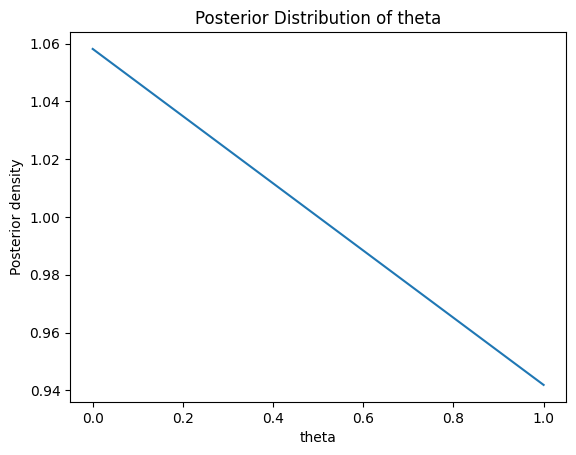

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln

x = np.array([9,9,8,6,7,5])
C_A = np.array([115,95,54,52,55,55])
C_B = np.array([95,115,57,55,55,57])
alpha0 = np.ones(6)

def log_dirichlet_multinomial(x, C, alpha0):
    term1 = gammaln(np.sum(C + alpha0)) - gammaln(np.sum(C + alpha0 + x))
    term2 = np.sum(gammaln(C + alpha0 + x) - gammaln(C + alpha0))
    term3 = gammaln(np.sum(x) + 1) - np.sum(gammaln(x + 1))
    return term1 + term2 + term3

log_LA = log_dirichlet_multinomial(x, C_A, alpha0)
log_LB = log_dirichlet_multinomial(x, C_B, alpha0)

LA = np.exp(log_LA)
LB = np.exp(log_LB)

theta = np.linspace(0,1,1000)
posterior = 2*(theta*LA + (1-theta)*LB)/(LA+LB)

plt.plot(theta, posterior)
plt.xlabel("theta")
plt.ylabel("Posterior density")
plt.title("Posterior Distribution of theta")
plt.show()